# Arabic Sign Language Recognition Models Training

This notebook contains the implementation, training, and evaluation of multiple deep learning and computer vision approaches for Arabic Sign Language alphabet recognition, including CNN and MobileNetV2 models.

In [1]:
from google.colab import drive

# ======================================
# 2. ربط Drive
# ======================================
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import cv2
import shutil
import random
from pathlib import Path

ORIGINAL_DATA_DIR = "/content/drive/MyDrive/merged_dataset_ArSL_rgb_New"
REAL_DATA_DIR = "/content/drive/MyDrive/Testing-data-Arabic-sign-language "
OUTPUT_DIR = "/content/drive/MyDrive/arabic_merged_split_dataset2"
IMG_SIZE = (224, 224)
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

In [ ]:
def preprocess_and_save(img_path, save_path):
    img = cv2.imread(img_path)
    if img is None:
        return False
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape
    crop = img_rgb[
        int(h * 0.15):int(h * 0.85),
        int(w * 0.15):int(w * 0.85)
    ]
    resized = cv2.resize(crop, IMG_SIZE)
    resized_bgr = cv2.cvtColor(resized, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, resized_bgr)
    return True

In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/merged_dataset_ArSL_rgb_New"

print("📊 عدد الصور لكل كلاس:\n")
total = 0
for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        total += count
        print(f"  {class_name:<15} {count} صورة")

print(f"\n✅ المجموع الكلي: {total} صورة")

📊 عدد الصور لكل كلاس:

  ain             2358 صورة
  al              1619 صورة
  aleff           1959 صورة
  bb              2098 صورة
  dal             1869 صورة
  dha             1945 صورة
  dhad            1936 صورة
  fa              2210 صورة
  gaaf            1924 صورة
  ghain           2207 صورة
  ha              1845 صورة
  haa             1772 صورة
  jeem            1762 صورة
  kaaf            2038 صورة
  khaa            1853 صورة
  la              2014 صورة
  laam            2092 صورة
  meem            2018 صورة
  nun             2056 صورة
  ra              1886 صورة
  saad            2165 صورة
  seen            1904 صورة
  sheen           1785 صورة
  ta              2042 صورة
  taa             2149 صورة
  thaa            2071 صورة
  thal            1784 صورة
  toot            2048 صورة
  waw             1620 صورة
  ya              1994 صورة
  yaa             1293 صورة
  zay             1575 صورة

✅ المجموع الكلي: 61891 صورة


In [ ]:
print("📊 عدد الصور لكل كلاس بعد الدمج:\n")
from collections import Counter

class_counts = Counter()
for img_path, class_name in all_images:
    class_counts[class_name] += 1

total = 0
for class_name in sorted(class_counts.keys()):
    count = class_counts[class_name]
    total += count
    print(f"  {class_name:<15} {count} صورة")

print(f"\n✅ المجموع الكلي: {total} صورة")

📊 عدد الصور لكل كلاس بعد الدمج:

  ain             2388 صورة
  al              1649 صورة
  aleff           1989 صورة
  bb              2128 صورة
  dal             1899 صورة
  dha             1975 صورة
  dhad            1966 صورة
  fa              2240 صورة
  gaaf            1954 صورة
  ghain           2237 صورة
  ha              1876 صورة
  haa             1801 صورة
  jeem            1790 صورة
  kaaf            2068 صورة
  khaa            1882 صورة
  la              2044 صورة
  laam            2122 صورة
  meem            2047 صورة
  nun             2086 صورة
  ra              1916 صورة
  saad            2195 صورة
  seen            1934 صورة
  sheen           1815 صورة
  ta              2071 صورة
  taa             2179 صورة
  thaa            2101 صورة
  thal            1814 صورة
  toot            2078 صورة
  waw             1650 صورة
  ya              2024 صورة
  yaa             1323 صورة
  zay             1605 صورة

✅ المجموع الكلي: 62846 صورة


In [ ]:
valid_ext = (".jpg", ".jpeg", ".png")
all_images = []

for data_dir in [ORIGINAL_DATA_DIR, REAL_DATA_DIR]:
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        class_name = class_name.strip()
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(valid_ext):
                img_path = os.path.join(class_path, img_name)
                all_images.append((img_path, class_name))

print("Total images found:", len(all_images))

Total images found: 62846


In [ ]:
src = "/content/drive/MyDrive/merged_dataset_ArSL_rgb_New"
dst = "/content/merged_dataset_ArSL_rgb_New3/"

if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print("✅ Done copying")
else:
    print("✅ Already exists")

✅ Done copying


In [ ]:
from sklearn.model_selection import train_test_split

# تجميع الصور حسب الكلاس
from collections import defaultdict
class_images = defaultdict(list)
for img_path, class_name in all_images:
    class_images[class_name].append(img_path)

# تقسيم كل كلاس بشكل منفصل عشان يكون متوازن
train_list, val_list, test_list = [], [], []

for class_name, imgs in class_images.items():
    random.shuffle(imgs)
    train, temp = train_test_split(imgs, test_size=(val_ratio + test_ratio), random_state=42)
    val, test = train_test_split(temp, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42)

    train_list += [(p, class_name) for p in train]
    val_list   += [(p, class_name) for p in val]
    test_list  += [(p, class_name) for p in test]

print(f"✅ Train: {len(train_list)}")
print(f"✅ Val:   {len(val_list)}")
print(f"✅ Test:  {len(test_list)}")

✅ Train: 43977
✅ Val:   9424
✅ Test:  9445


In [ ]:
import os
import shutil

SPLIT_DIR = "/content/arabic_split_dataset"

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(SPLIT_DIR, split), exist_ok=True)

def copy_images(data_list, split_name):
    for img_path, class_name in data_list:

        class_dir = os.path.join(SPLIT_DIR, split_name, class_name)
        os.makedirs(class_dir, exist_ok=True)

        filename = os.path.basename(img_path)

        shutil.copy(
            img_path,
            os.path.join(class_dir, filename)
        )

copy_images(train_list, 'train')
copy_images(val_list, 'val')
copy_images(test_list, 'test')

print("✅ Dataset Ready")

✅ Dataset Ready


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    "/content/arabic_split_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "/content/arabic_split_dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 43968 images belonging to 32 classes.
Found 9423 images belonging to 32 classes.


# The first Model **CNN**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

num_classes = len(train_generator.class_indices)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,088 (42.62 MB)

 Trainable params: 11,173,088 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 109s 74ms/step - accuracy: 0.6556 - loss: 1.2854 - val_accuracy: 0.8268 - val_loss: 0.6617
Epoch 2/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 88s 64ms/step - accuracy: 0.8874 - loss: 0.4103 - val_accuracy: 0.8478 - val_loss: 0.6107
Epoch 3/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 87s 63ms/step - accuracy: 0.9466 - loss: 0.1825 - val_accuracy: 0.8493 - val_loss: 0.8070
Epoch 4/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 87s 63ms/step - accuracy: 0.9709 - loss: 0.1002 - val_accuracy: 0.8448 - val_loss: 0.9130
Epoch 5/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 92s 67ms/step - accuracy: 0.9804 - loss: 0.0682 - val_accuracy: 0.8441 - val_loss: 1.2982
Epoch 6/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 91s 66ms/step - accuracy: 0.9837 - loss: 0.0574 - val_accuracy: 0.8435 - val_loss: 1.2813
Epoch 7/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 88s 64ms/step - accuracy: 0.9881 - loss: 0.0436 - val_accuracy: 0.8453 - val_loss: 1.4483
Epoch 8/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 88s 64ms/step - accuracy: 0.9893 

In [ ]:
model.save("/content/drive/MyDrive/arabic_sign_cnn_model3.h5")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [ ]:
test_generator = val_datagen.flow_from_directory(
    "/content/arabic_split_dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Found 9445 images belonging to 32 classes.
296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8634 - loss: 1.3251
Test Loss: 1.3250876665115356
Test Accuracy: 0.863419771194458


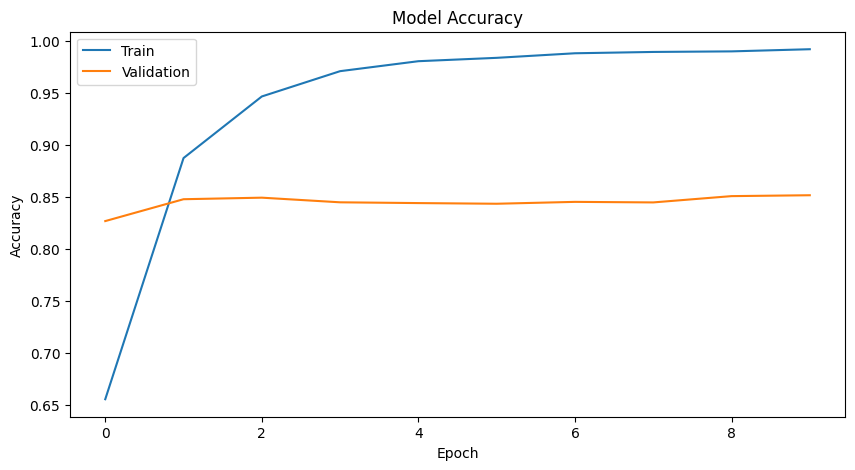

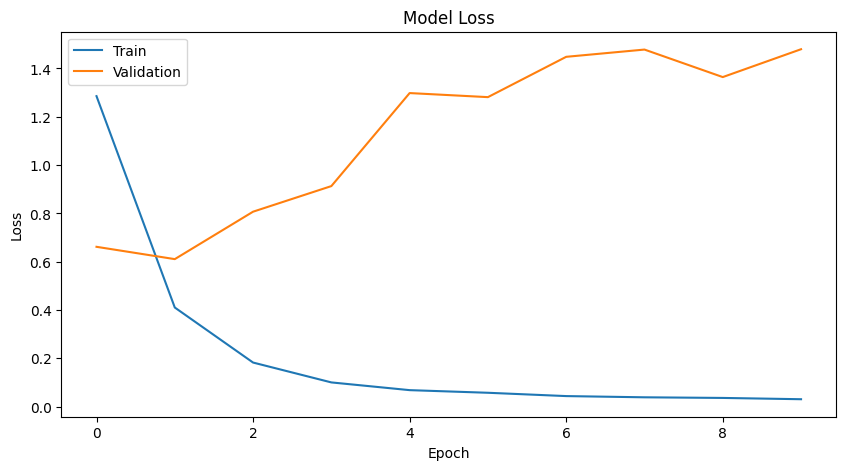

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# Loss
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# The Second model MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

num_classes = len(train_generator.class_indices)

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,080 (9.25 MB)

 Trainable params: 168,096 (656.62 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 132s 78ms/step - accuracy: 0.3473 - loss: 2.3107 - val_accuracy: 0.7176 - val_loss: 1.1819
Epoch 2/30
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 72s 52ms/step - accuracy: 0.6065 - loss: 1.2976 - val_accuracy: 0.7989 - val_loss: 0.8069
Epoch 3/30
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.6914 - loss: 1.0086 - val_accuracy: 0.8330 - val_loss: 0.6379
Epoch 4/30
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0.7400 - loss: 0.8406 - val_accuracy: 0.8565 - val_loss: 0.5527
Epoch 5/30
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 77s 56ms/step - accuracy: 0.7732 - loss: 0.7371 - val_accuracy: 0.8718 - val_loss: 0.4889
Epoch 6/30
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 71s 52ms/step - accuracy: 0.7996 - loss: 0.6570 - val_accuracy: 0.8857 - val_loss: 0.4437
Epoch 7/30
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 69s 50ms/step - accuracy: 0.8181 - loss: 0.5984 - val_accuracy: 0.8947 - val_loss: 0.4076
Epoch 8/30
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0.8312 

In [ ]:
model.save("/content/drive/MyDrive/mobilenet_arabic_sign_model8.h5")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [ ]:
test_generator = val_datagen.flow_from_directory(
    "/content/arabic_split_dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Found 9445 images belonging to 32 classes.
296/296 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.9353 - loss: 0.2207
Test Loss: 0.22072292864322662
Test Accuracy: 0.9353097081184387


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# مهم جدًا
val_generator.reset()

pred = model.predict(
    val_generator,
    steps=len(val_generator),
    verbose=1
)

y_pred = np.argmax(pred, axis=1)
y_true = val_generator.classes

class_names = list(val_generator.class_indices.keys())

print("y_true length:", len(y_true))
print("y_pred length:", len(y_pred))
print("classes:", class_names)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

295/295 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step
y_true length: 9424
y_pred length: 9424
classes: ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 'ya', 'yaa', 'zay']
              precision    recall  f1-score   support

         ain       0.97      0.96      0.96       358
          al       0.95      0.96      0.96       247
       aleff       0.97      0.96      0.97       298
          bb       0.94      0.93      0.94       319
         dal       0.89      0.90      0.90       285
         dha       0.94      0.91      0.93       296
        dhad       0.94      0.93      0.93       295
          fa       0.91      0.89      0.90       336
        gaaf       0.89      0.91      0.90       293
       ghain       0.93      0.95      0.94       336
          ha       0.90      0.92      0.91       281
         haa       0.91 

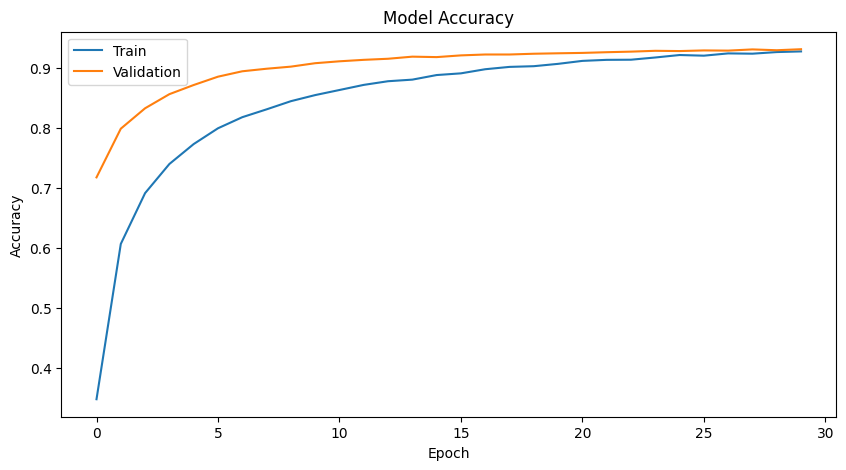

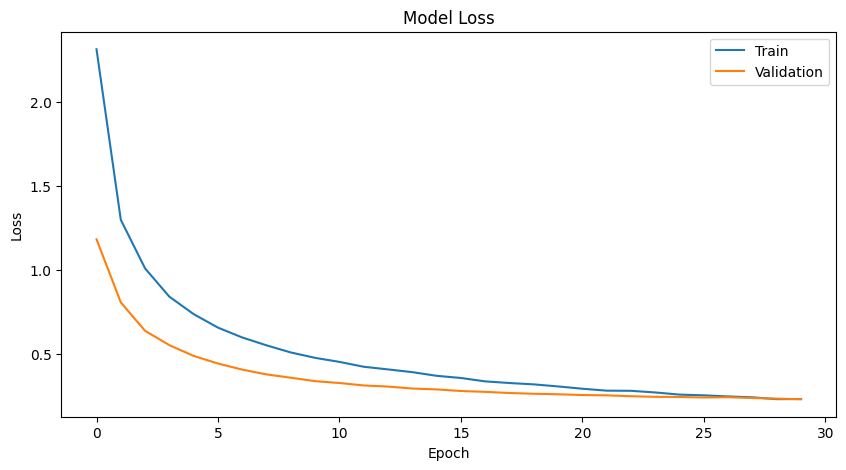

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# Loss
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Prediction: yaa


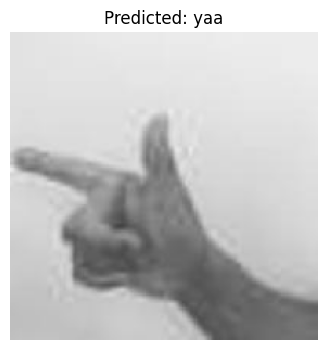

In [ ]:
import numpy as np
import random
from tensorflow.keras.preprocessing import image

class_names = list(train_generator.class_indices.keys())

img_path = random.choice(test_generator.filepaths)

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')

print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: ain


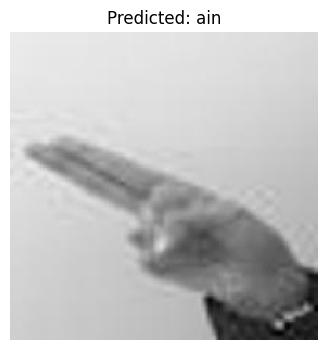

In [ ]:
import numpy as np
import random
from tensorflow.keras.preprocessing import image

class_names = list(train_generator.class_indices.keys())

img_path = random.choice(test_generator.filepaths)

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')

print("Prediction:", predicted_class)

# camera testing

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction: la
Confidence: 48.05 %

Top 3 predictions:
la : 48.05 %
dha : 12.82 %
ya : 11.28 %


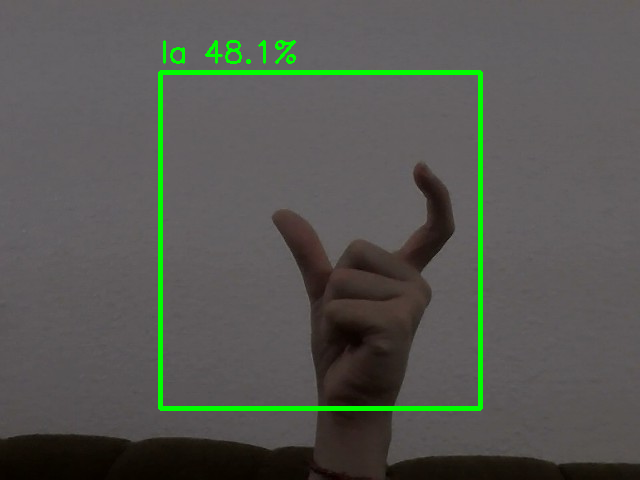

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# 1) حملي المودل
model = tf.keras.models.load_model("/content/drive/MyDrive/mobilenet_arabic_sign_model4.h5")

# 2) اكتبي أسماء الكلاسات بنفس ترتيب التدريب
class_names = [
    'ain','al','aleff','bb','dal','dha','dhad','fa',
    'gaaf','ghain','ha','haa','jeem','kaaf','khaa','la',
    'laam','meem','nun','ra','saad','seen','sheen','ta',
    'taa','thaa','thal','toot','waw','ya','yaa','zay'
]

# غيريها حسب حجم التدريب عندك
IMG_SIZE = (224,224)   # إذا دربتي على 224 خليها (224,224)

def take_photo(filename='photo.jpg', quality=0.9):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');
      button.textContent = 'Capture';
      div.appendChild(video);
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

def predict_live_image():
    img_path = take_photo()

    img = cv2.imread(img_path)
    img = cv2.flip(img, 1)  # عكس الكاميرا إذا احتجتي

    # قص منطقة اليد من منتصف الصورة
    h, w, _ = img.shape
    x1, y1 = int(w*0.25), int(h*0.15)
    x2, y2 = int(w*0.75), int(h*0.85)
    roi = img[y1:y2, x1:x2]

    # نفس preprocessing حق التدريب
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    roi_resized = cv2.resize(roi_rgb, IMG_SIZE)
    roi_norm = roi_resized / 255.0
    input_img = np.expand_dims(roi_norm, axis=0)

    preds = model.predict(input_img)[0]
    pred_index = np.argmax(preds)
    pred_class = class_names[pred_index]
    confidence = preds[pred_index] * 100

    print("Prediction:", pred_class)
    print("Confidence:", round(confidence, 2), "%")

    top3 = np.argsort(preds)[-3:][::-1]
    print("\nTop 3 predictions:")
    for i in top3:
        print(class_names[i], ":", round(preds[i]*100, 2), "%")

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
    cv2.putText(img, f"{pred_class} {confidence:.1f}%",
                (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                1, (0,255,0), 2)

    cv2_imshow(img)

predict_live_image()

# Text → Sign Image Retrieval

In [12]:
arabic_letters = {

            "ain": "ع",
            "al": "ال",
            "aleff": ["ا", "إ", "أ"],

            "bb": "ب",

            "dal": "د",
            "dha": "ظ",
            "dhad": "ض",

            "fa": "ف",

            "gaaf": "ق",
            "ghain": "غ",

            "ha": "ه",
            "haa": "ح",

            "jeem": "ج",

            "kaaf": "ك",
            "khaa": "خ",

            "la": "لا",
            "laam": "ل",

            "meem": "م",

            "nun": "ن",

            "ra": "ر",

            "saad": "ص",
            "seen": "س",
            "sheen": "ش",

            "ta": "ط",
            "taa": "ت",

            "thaa": "ث",
            "thal": "ذ",

            "toot": "ة",

            "waw": "و",

            "ya": "ي",
            "yaa": "ئ",

            "zay": "ز"
        }

In [11]:
import os
import random
import cv2
import matplotlib.pyplot as plt

DATA_DIR = "/content/drive/MyDrive/merged_dataset_ArSL_rgb_New"

# Create arabic_to_class dictionary from arabic_letters
arabic_to_class = {}
for class_name, arabic_chars in arabic_letters.items():
    if isinstance(arabic_chars, list):
        for char in arabic_chars:
            arabic_to_class[char] = class_name
    else:
        arabic_to_class[arabic_chars] = class_name

def show_sign_for_letter(ar_letter):
    if ar_letter not in arabic_to_class:
        print("الحرف غير موجود في القاموس")
        return

    class_name = arabic_to_class[ar_letter]
    class_path = os.path.join(DATA_DIR, class_name)

    if not os.path.exists(class_path):
        print("فولدر الكلاس غير موجود:", class_path)
        return

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(images) == 0:
        print("لا توجد صور داخل هذا الكلاس")
        return

    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"{ar_letter} → {class_name}")
    plt.axis("off")
    plt.show()

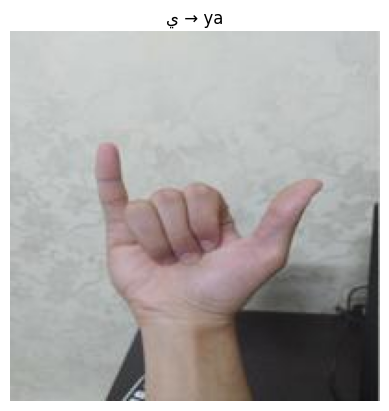

In [13]:
show_sign_for_letter("ي")